In [92]:
import pandas as pd
import numpy as np

from models_tests.arimas.arima_pipeline import ARIMAPipeline
from models_tests.ETS_HoltsWinter.ets_pipeline import ETSPipeline
from models_tests.tcn.pipeline import TCNPipeline 
from dl_model.pipeline_lstm import LSTMWrapper
from analyse.modele_comparaison import compare_models

In [95]:
# LOAD DATA
df = pd.read_csv("WADI_clean.csv")

target = "3_LT_001_PV"

# features = tout sauf target
X = df.drop(columns=[target])
y = df[target]

# Valeurs manquantes complétées
X = X.ffill()

# garder que numérique
X = X.select_dtypes(include=[np.number])


# SPLIT (time series)
split_1 = int(len(df) * 0.7)
split_2 = int(len(df) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test = X.iloc[split_2:]
y_test = y.iloc[split_2:]

y_train_val = pd.concat([y_train, y_val])
X_train_val = pd.concat([X_train, X_val])

X_train_val = X_train_val.loc[:, X_train_val.var() > 0]
X_test_2 = X_test[X_train_val.columns]
# garder features variables sur une journée

def filter_features(df, min_unique=4):
    cols_to_keep = []

    for col in df.columns:
        if df[col].nunique() >= min_unique:
            cols_to_keep.append(col)

    return cols_to_keep

top_cols = filter_features(X_train_val, min_unique=4)           
2

X_train_val = X_train_val[top_cols]
X_train = X_train[top_cols]
X_val = X_val[top_cols]
X_test = X_test[top_cols]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test :", X_test.shape)

Train: (142881, 66)
Validation: (30617, 66)
Test : (30618, 66)


# Modifs spécifiques aux ARIMAs

In [78]:
pipe = ARIMAPipeline()
pipe.fit(y_train_val, X_train=X_train_val)

{'model': ARIMA(order=(5, 1, 3), scoring_args={}, suppress_warnings=True,
       with_intercept=False),
 'model_trend': None,
 'season_pattern': None,
 'min_train': None,
 'rmse': None,
 'mae': None}

In [79]:
pred_arima = pipe.predict(
    n_steps=len(y_test),      # longueur du test
    X_future=X_test,          # si exogènes
    n_train=len(y_train_val)  # indique au modèle où commence la prédiction
)

In [80]:
pipe = ETSPipeline()
pipe.fit(y_train_val)


preds_ets = pipe.predict(len(y_test))

C:\Users\ELEVEN\miniconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


In [81]:
import pickle

with open("outputs/forecast_results.pkl", "rb") as f:
    results = pickle.load(f)

preds_ets = results["pred_ets"]
pred_arima = results["pred_arima"]
y_test = results["y_test"]

# LSTM

In [82]:
pipe = LSTMWrapper()

pipe.fit(X_train, y_train, X_val, y_val)

C:\Users\ELEVEN\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 30, 64)              │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
pred_lstm = pipe.predict(X_test, len(y_test))
preds_lstm = pd.Series(
    pred_lstm.flatten(),
    index=X_test.index
)

In [84]:
# import pickle

# with open("outputs/forecast_results.pkl", "rb") as f:
#     results = pickle.load(f)

# preds_ets = results["pred_ets"]
# pred_arima = results["pred_arima"]
# pred_lstm = results["pred_lstm"]
# y_test = results["y_test"]

# TCN

In [85]:
train_df = pd.concat([y_train.rename("target"), X_train], axis=1)
val_df = pd.concat([y_val.rename("target"), X_val], axis=1)

In [86]:
pipe = TCNPipeline()

pipe.fit(train_df, val_df)

(<Functional name=functional_4, built=True>,
 None,
 <keras.src.callbacks.history.History at 0x2822ff568d0>)

In [87]:
X_last = X_test[-pipe.seq_len:].values
X_last = X_last.reshape(1, pipe.seq_len, X_last.shape[1])

In [88]:
preds_tcn = pipe.predict(X_last, n_steps=len(y_test))

In [89]:
preds_tcn = pd.Series(
    preds_tcn.flatten(),
    index=X_test.index
)

In [90]:
results = {"ARIMA" : {"pred": pred_arima}, "ETS" : {"pred": preds_ets}, "LSTM" : {"pred": preds_lstm_series}, "TCN" : {"pred": preds_tcn}}

COMPARAISON MODELES
   model      RMSE       MAE  SkillScore
2   LSTM  1.371041  0.953406  -25.011745
0  ARIMA  1.518637  0.976383  -27.811976
3    TCN  1.682484  1.161957  -30.920527
1    ETS  1.799464  1.367173  -33.139884


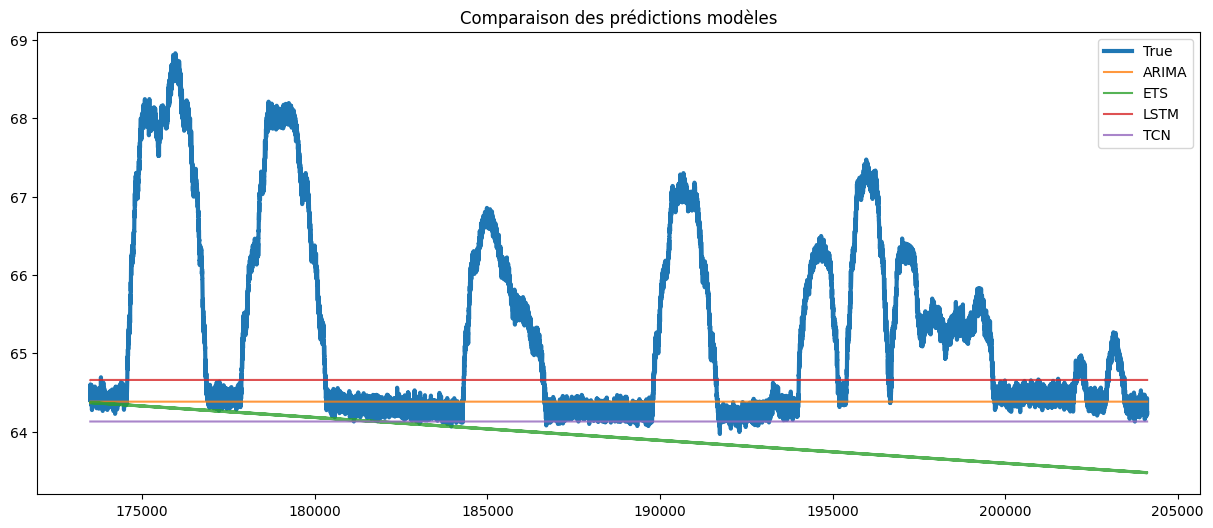

In [91]:
df_compare = compare_models(results_dict=results, y_true=y_test)